In [ ]:
import os
import time
import requests
import numpy as np
import pandas as pd
# import urllib.request
# from bs4 import BeautifulSoup
from dotenv import load_dotenv
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


### Functions
- get_puuid(game_name, tag_line)
- get_match_ids(puuid)
- get_match_data(game_id)
- get_player_rank(puuid)
- get_player_champion_mastery(puuid, champion_id)

In [2]:
load_dotenv()

API_KEY = os.getenv("RIOT_API_KEY")
HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/149.0.0.0 Safari/537.36",
    "Accept-Language": "en-US,en;q=0.9",
    "Accept-Charset": "application/x-www-form-urlencoded; charset=UTF-8",
    "Origin": "https://developer.riotgames.com"
}

In [11]:
def get_puuid(game_name, tag_line):
    '''
    Get Riot's Player Universally Unique Identify (PUUID)

    Args:
        - game_name: (string)
        - tag_line: (string)

    Returns:
        - payload response with keys: [puuid, gamename, tag] (dictionary)
    '''
    url = f'https://americas.api.riotgames.com/riot/account/v1/accounts/by-riot-id/{game_name}/{tag_line}?api_key={API_KEY}'

    try:
        response = requests.get(url, headers=HEADERS)

        response.raise_for_status()
        
        json_response = response.json()
    except Exception as e:
        print(f"Error fetching URL: {e.reason}")

    return json_response['puuid']

In [4]:
def get_match_ids(puuid, start_time=1623801600, end_time=int(time.time()), game_type='ranked'):
    ''' 
    Top ID will be the last played game
    '''
    url = f'https://americas.api.riotgames.com/lol/match/v5/matches/by-puuid/{puuid}/ids?startTime={start_time}&endTime={end_time}&type={game_type}&start=0&count=20&api_key={API_KEY}'

    try:
        response = requests.get(url, headers=HEADERS)

        response.raise_for_status()
        
        json_response = response.json()
    except Exception as e:
        print(f"Error fetching URL: {e.reason}")

    return json_response
        

In [5]:
def get_match_data(match_id):
    ''' 

    Returns:
        - Dictionary of match data:
            - match_data
            - timeline_data
    '''
    match_url = f'https://americas.api.riotgames.com/lol/match/v5/matches/{match_id}?api_key={API_KEY}'
    timeline_url = f'https://americas.api.riotgames.com/lol/match/v5/matches/{match_id}/timeline?api_key={API_KEY}'
    try:
        match_response = requests.get(match_url, headers=HEADERS)
        timeline_response = requests.get(timeline_url, headers=HEADERS)

        match_response.raise_for_status()
        timeline_response.raise_for_status()

        match_json_response = match_response.json()
        timeline_json_response = timeline_response.json()

        output = {
            'match_data': match_json_response,
            'timeline_data': timeline_json_response
        }
    except Exception as e:
        print(f"Error fetching URL: {e.reason}")

    return output

In [6]:
def get_player_rank(puuid):
    ''' 
    '''
    url = f'https://na1.api.riotgames.com/lol/league/v4/entries/by-puuid/{puuid}?api_key={API_KEY}'

    try:
        response = requests.get(url, headers=HEADERS)

        response.raise_for_status()
        
        json_response = response.json()
    except Exception as e:
        print(f"Error fetching URL: {e.reason}")

    return json_response

In [7]:
def get_player_champion_mastery(puuid, champion_id):
    ''' 
    '''
    url = f'https://na1.api.riotgames.com/lol/champion-mastery/v4/champion-masteries/by-puuid/{puuid}/by-champion/{champion_id}?api_key={API_KEY}'
    
    try:
        response = requests.get(url, headers=HEADERS)

        response.raise_for_status()
        
        json_response = response.json()
    except Exception as e:
        print(f"Error fetching URL: {e.reason}")

    return json_response

In [12]:
puuid = get_puuid('coolguy', 'super')
player_rank = get_player_rank(puuid=puuid) 
match_ids = get_match_ids(puuid=puuid)
game_data = get_match_data(match_ids[0])

In [18]:
match_data = game_data['match_data']
timeline_data = game_data['timeline_data']

In [39]:
participantids = []
playerpuuids = []

for player in timeline_data['info']['participants']:
    participantId = player['participantId']
    playerPuuid = player['puuid']

    if len(playerPuuid) != 78:
        print(f'Error Getting Puuid for Participant {participantId}')
        playerPuuid = np.nan

    participantids.append(participantId)
    playerpuuids.append(playerPuuid)

if len(participantids) != len(playerpuuids):
    print('Error creating dataframe')
else:
    data = {
        'player_number': participantids,
        'puuid': playerpuuids
    }

    player_map = pd.DataFrame(data)

In [97]:
player_map

,player_number,puuid
0,1,QGO2HPMja_X-VArOvSRzXlqX2EazclkHYgsF9jG5Grjp2H...
1,2,pR7PvWgyM43_w29eGCqUG7lxi3vhBXWOpHCgkYG3y--QIf...
2,3,ar_jyWmlpNjSHR-TdEO5-B0xAKsBTjLRMzfFCquTD9IEk3...
3,4,9xEO9V_Z8K0_KxNbxYY1aayU3VAw8iW2CyrIM-_M6oeEih...
4,5,Pz5YNebycnGMT8Oj5nv_FK1SgwVJmMvWWqQsuLehYKMdFb...
5,6,CP7n_1eS-Elx0Rckzlh3pfISusBijf3NJGhdxaeE8D1ajQ...
6,7,JWsmLVScuoT6C_q1fLPihUz0OjPSdPUyDn7fs3NnS3AuPU...
7,8,NmNFE8qkNQ4fpRhD-4toh-8A57vJ9eT9QzITecujiBZ5_d...
8,9,YhlFTAcDzvLH00sBO3oBuV-xY4-3w9ztCo4NKLqJIG0z3O...
9,10,Fyz4l3jLG7u1tN3MJXPwI_jx9SdFuC2w3pXjO5HsvgGvc4...


In [123]:
### this is only the first frame of the game and player

frames = []
for i in range(len(timeline_data['info']['frames'])):
    for player in player_map['player_number'].to_list():
        frame = timeline_data['info']['frames'][i]['participantFrames'][f'{player}']

        champ_stats = frame['championStats']
        damage_stats = frame['damageStats']
        position = frame['position']

        keys = [
            key for key in list(
                frame.keys()
            ) if key not in ['championStats', 'damageStats', 'position']
        ]

        misc_stats = {key: frame[key] for key in keys}

        frame_stats = champ_stats | damage_stats | misc_stats | position

        frame_stats['currentFrame'] = i + 1

        frames.append(frame_stats)

timeline_data = pd.DataFrame(frames)

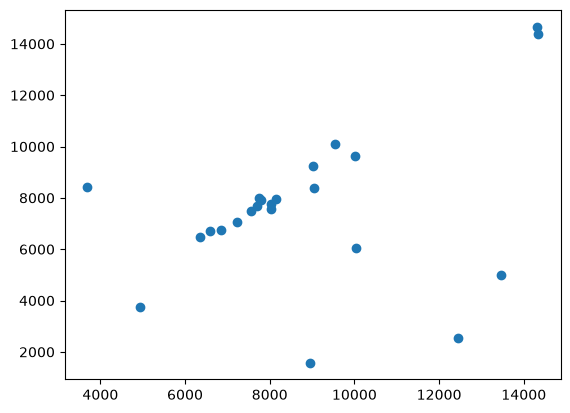

In [135]:
my_data = timeline_data[timeline_data['participantId'] == 8]

plt.scatter(data=my_data[['x', 'y']], x='x', y='y')
plt.show()